In [ ]:
import zipfile
from google.colab import files
import os

print("Please upload your zipped image dataset folder (e.g., 'images.zip').")

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  # Assuming the uploaded file is a zip archive
  try:
    with zipfile.ZipFile(fn, 'r') as zip_ref:
      zip_ref.extractall(os.path.join(os.getcwd(), 'dataset')) # Extract to a 'dataset' folder
    print(f'Successfully extracted "{fn}" to the "dataset" folder.')
  except zipfile.BadZipFile:
    print(f'Error: "{fn}" is not a valid zip file. Please upload a zip archive.')
  except Exception as e:
    print(f'An unexpected error occurred: {e}')

# List the contents of the created 'dataset' folder to confirm
if os.path.exists('dataset'):
  print('\nContents of the \'dataset\' folder:')
  for root, dirs, files in os.walk('dataset'):
    level = root.replace('dataset', '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
      print(f'{subindent}{f}')
else:
  print('\nNo \'dataset\' folder was created.')

Please upload your zipped image dataset folder (e.g., 'images.zip').


Saving Flower_Dataset.zip to Flower_Dataset.zip
User uploaded file "Flower_Dataset.zip" with length 215160703 bytes
Successfully extracted "Flower_Dataset.zip" to the "dataset" folder.

Contents of the 'dataset' folder:
dataset/
    Flower_Dataset/
        test/
            Image_611.jpg
            Image_223.jpg
            Image_354.jpg
            Image_763.jpg
            Image_692.jpg
            Image_8.jpg
            Image_53.jpg
            Image_618.jpg
            Image_502.jpg
            Image_590.jpg
            Image_664.jpg
            Image_22.jpg
            Image_659.jpg
            Image_480.jpg
            Image_248.jpg
            Image_408.jpg
            Image_350.jpg
            Image_613.jpg
            Image_429.jpg
            Image_145.jpg
            Image_81.jpg
            Image_67.jpg
            Image_639.jpg
            Image_2.jpg
            Image_454.jpg
            Image_789.jpg
            Image_146.jpg
            Image_784.jpg
            Image

### Set up the directory paths and data generators

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Define the base directory where the dataset was extracted
base_dir = './dataset/Flower_Dataset'

# Define train and validation directories
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'test') # Corrected to 'test' based on dataset structure

# Check if directories exist
if not os.path.exists(train_dir):
    print(f"Error: Training directory not found at {train_dir}")
if not os.path.exists(validation_dir):
    print(f"Error: Validation directory not found at {validation_dir}")

# Image dimensions and batch size
IMG_HEIGHT = 227  # AlexNet input size
IMG_WIDTH = 227   # AlexNet input size
BATCH_SIZE = 32

In [ ]:
# Data augmentation and normalization for training
# We'll use validation_split to get validation data from the training set
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # Allocate 20% of training data for validation
)

# Flow training images in batches from directory 'train_dir'
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training' # Specify this is the training subset
)

# Flow validation images in batches from directory 'train_dir' (using the validation split)
validation_generator = train_datagen.flow_from_directory(
    train_dir, # Point to the training directory to get validation split
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation' # Specify this is the validation subset
)

# Get the number of classes from the train generator
num_classes = train_generator.num_classes
print(f"Number of classes: {num_classes}")

Found 2198 images belonging to 5 classes.
Found 548 images belonging to 5 classes.
Number of classes: 5


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    # 1st Convolutional Layer
    Conv2D(filters=96, kernel_size=(11,11), strides=(4,4), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3,3), strides=(2,2)),

    # 2nd Convolutional Layer
    Conv2D(filters=256, kernel_size=(5,5), strides=(1,1), activation='relu', padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3,3), strides=(2,2)),

    # 3rd Convolutional Layer
    Conv2D(filters=384, kernel_size=(3,3), strides=(1,1), activation='relu', padding="same"),
    BatchNormalization(),

    # 4th Convolutional Layer
    Conv2D(filters=384, kernel_size=(3,3), strides=(1,1), activation='relu', padding="same"),
    BatchNormalization(),

    # 5th Convolutional Layer
    Conv2D(filters=256, kernel_size=(3,3), strides=(1,1), activation='relu', padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3,3), strides=(2,2)),

    # Flattening
    Flatten(),

    # 1st Fully Connected Layer
    Dense(4096, activation='relu'),
    Dropout(0.5),

    # 2nd Fully Connected Layer
    Dense(4096, activation='relu'),
    Dropout(0.5),

    # Output Layer
    Dense(num_classes, activation='softmax') # num_classes from the data generator
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 55, 55, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 27, 27, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 13, 13, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 13, 13, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 13, 13, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │        20,485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,307,333 (222.42 MB)

 Trainable params: 58,304,581 (222.41 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [ ]:
epochs = 30 # You can adjust the number of epochs

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

print("Model training complete.")

Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 414s 6s/step - accuracy: 0.3680 - loss: 11.5717 - val_accuracy: 0.1967 - val_loss: 20.4604
Epoch 2/30
 1/68 ━━━━━━━━━━━━━━━━━━━━ 6:36 6s/step - accuracy: 0.4375 - loss: 4.4294

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 33s 403ms/step - accuracy: 0.4375 - loss: 4.4294 - val_accuracy: 0.1820 - val_loss: 19.7930
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 475s 6s/step - accuracy: 0.3873 - loss: 2.2597 - val_accuracy: 0.3566 - val_loss: 1.5642
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 40s 522ms/step - accuracy: 0.3125 - loss: 2.0017 - val_accuracy: 0.3658 - val_loss: 1.5933
Epoch 5/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 460s 6s/step - accuracy: 0.4418 - loss: 1.6248 - val_accuracy: 0.4007 - val_loss: 1.5951
Epoch 6/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 41s 522ms/step - accuracy: 0.4375 - loss: 1.7726 - val_accuracy: 0.3603 - val_loss: 1.6542
Epoch 7/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 502s 7s/step - accuracy: 0.4958 - loss: 1.4172 - val_accuracy: 0.3787 - val_loss: 1.5374
Epoch 8/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 33s 405ms/step - accuracy: 0.3750 - loss: 1.6455 - val_accuracy: 0.3585 - val_loss: 1.6223
Epoch 9/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 445s 7s/step - accuracy: 0.5162 - loss: 1.3330 - val_accuracy: 0.4081 - val

In [ ]:
loss, accuracy = model.evaluate(validation_generator)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.5310 - loss: 1.2185
Validation Loss: 1.2185
Validation Accuracy: 0.5310


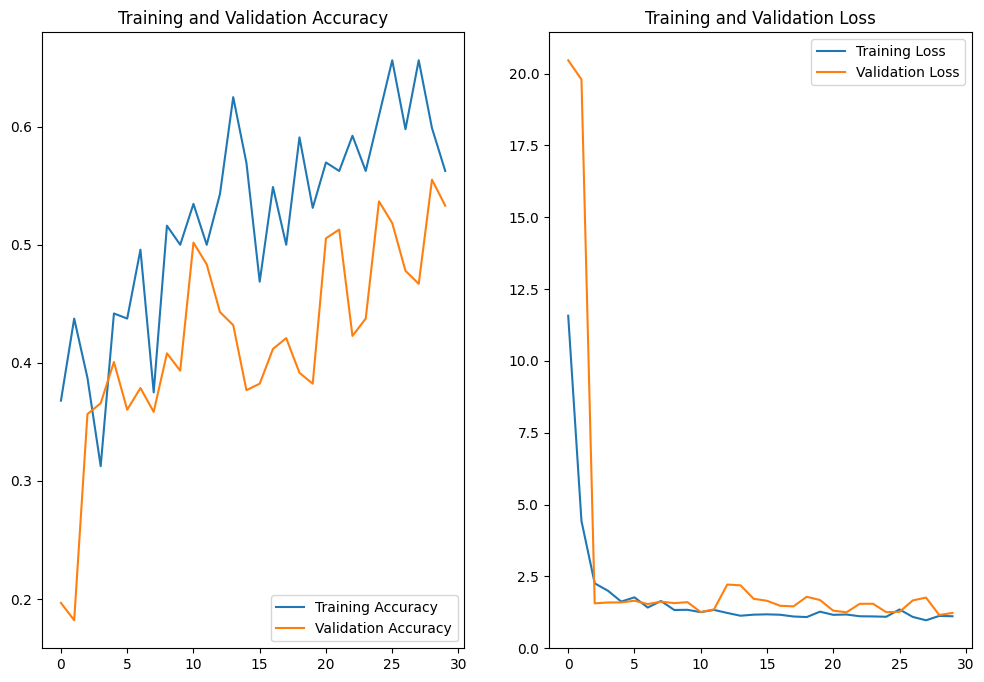

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()